<h1 style="color: red; font-size: 48px; text-align: center;">Graph-Enhanced Real-Time Fraud Detection</h1>

<center>
    <img src="https://media.giphy.com/media/L1R1tvI9svkIWwpVYr/giphy.gif" alt="fraud detection network" height="220" width="520">
</center>


# 👋 Introduction

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The objective of this project is to build an <b>end-to-end streaming fraud-detection system</b> for the FinTech and payments industry that detects coordinated payment fraud in real time.
    It demonstrates how <b>graph signals</b> &mdash; the structure that links accounts, devices, and merchants &mdash; expose fraud rings that are invisible to any single transaction's features.
    Using a synthetic transaction stream that mirrors the <b>IEEE-CIS Fraud Detection</b> and <b>PaySim</b> datasets, we compute 15 real-time graph features on a sliding one-hour transaction graph, score every transaction with an XGBoost + CatBoost ensemble, and detect coordinated fraud rings with Label Propagation.
</div>

# 📚 Problem Statement

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Modern payment fraud is rarely the work of a lone actor &mdash; it is <b>coordinated</b>. Rings of mule accounts share a small pool of devices and hammer a handful of merchants in short bursts.
    On a single transaction's tabular features (amount, type, channel) this fraud is deliberately camouflaged and looks perfectly legitimate.
    The signal lives entirely in the <b>network structure</b>. The challenge is to surface that structure in real time, at high throughput, with exactly-once semantics, and turn it into a model signal that a single-transaction view cannot capture.
</div>

# 🔭 Feature Description

<div style="font-family:verdana; font-size: 20px; line-height: 1.7em;">
<p><b>Transactional features</b> (what a classic tabular model sees):</p>
<ol>
<li><p><strong><code>account_id</code></strong>: The account initiating the transaction.</p></li>
<li><p><strong><code>device_id</code></strong>: The device used &mdash; shared devices are the strongest mule-ring signal.</p></li>
<li><p><strong><code>merchant_id</code></strong>: The merchant receiving the payment.</p></li>
<li><p><strong><code>amount</code></strong>: Transaction value. Fraud amounts are camouflaged to mimic legitimate traffic.</p></li>
<li><p><strong><code>tx_type</code></strong>: PAYMENT, TRANSFER, CASH_OUT, DEBIT or CASH_IN.</p></li>
<li><p><strong><code>channel</code></strong>: web, mobile, pos or atm.</p></li>
<li><p><strong><code>timestamp</code> / <code>event_time</code></strong>: Event time used for the sliding-window graph.</p></li>
<li><p><strong><code>is_fraud</code></strong>: The binary target (1 = fraud, 0 = legitimate).</p></li>
</ol>

<p><b>The 15 graph features</b> (the network structure a tabular model is blind to):</p>
<ol>
<li><p><strong><code>account_degree</code></strong>: distinct devices + merchants for the account.</p></li>
<li><p><strong><code>account_pagerank</code></strong>: account centrality in the window graph.</p></li>
<li><p><strong><code>account_clustering_coef</code></strong>: how tightly the account's neighbours link.</p></li>
<li><p><strong><code>account_betweenness</code></strong>: bridge score of the account node.</p></li>
<li><p><strong><code>device_degree</code></strong>: accounts sharing the device (mule signal).</p></li>
<li><p><strong><code>device_betweenness_centrality</code></strong>: device as a bridge across the graph.</p></li>
<li><p><strong><code>device_pagerank</code></strong>: device centrality.</p></li>
<li><p><strong><code>device_shared_account_count</code></strong>: distinct accounts on the device.</p></li>
<li><p><strong><code>merchant_degree</code></strong>: distinct accounts hitting the merchant.</p></li>
<li><p><strong><code>merchant_cluster_coefficient</code></strong>: merchant neighbourhood density.</p></li>
<li><p><strong><code>merchant_betweenness</code></strong>: merchant as a bridge.</p></li>
<li><p><strong><code>velocity_ring_score</code></strong>: account transaction velocity in the window.</p></li>
<li><p><strong><code>component_size</code></strong>: size of the account's connected component.</p></li>
<li><p><strong><code>unique_devices_per_account</code></strong>: device fan-out for the account.</p></li>
<li><p><strong><code>unique_merchants_per_account</code></strong>: merchant fan-out for the account.</p></li>
</ol>

<p>
Together these capture the structural fingerprint of a coordinated fraud ring &mdash; the dense, shared-device subgraph &mdash; that no single transaction's features can reveal.
</p>
</div>

# 🎯 Project Goals

<div class="alert alert-block alert-warning" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li>Generate a realistic streaming transaction graph with planted, camouflaged fraud rings.</li>
        <li>Perform exploratory data analysis (EDA) on the transaction stream.</li>
        <li>Build a sliding-window transaction graph and engineer the 15 real-time graph features.</li>
        <li>Detect coordinated fraud rings with the Label Propagation Algorithm.</li>
        <li>Train and compare a <b>tabular-only</b> baseline against a <b>graph-enhanced</b> XGBoost + CatBoost ensemble, and quantify the AUC uplift.</li>
        <li>Turn each fraud probability into an <code>approve</code> / <code>challenge</code> / <code>decline</code> decision.</li>
    </ul>
</div>


# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from dataclasses import dataclass, field
from typing import Iterator

from rich.console import Console
from rich.table import Table

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set(font_scale=1.1)

# Generate the Transaction Stream

We generate a synthetic transaction stream that mirrors the structure of the PaySim / IEEE-CIS
datasets: each transaction links an **account**, a **device**, and a **merchant**. Legitimate
traffic spreads naturally across the graph, while a small number of **fraud rings** share devices
and hammer a handful of merchants &mdash; the coordinated pattern that is only visible in the graph.

In [2]:
TX_TYPES = ["PAYMENT", "TRANSFER", "CASH_OUT", "DEBIT", "CASH_IN"]
CHANNELS = ["web", "mobile", "pos", "atm"]


@dataclass
class GeneratorParams:
    total_transactions: int = 20_000
    n_accounts: int = 4_000
    n_devices: int = 2_500
    n_merchants: int = 800
    n_fraud_rings: int = 12
    fraud_ratio: float = 0.012
    window_minutes: int = 60
    seed: int = 42


class TransactionGenerator:
    """Generates a realistic transaction graph with planted fraud rings."""

    def __init__(self, params: GeneratorParams):
        self.p = params
        self.rng = np.random.default_rng(params.seed)
        self._fraud_ring_accounts = self._build_fraud_rings()
        # Legitimate "hub" devices: public terminals / shared family devices used
        # by many honest accounts -> benign high-degree nodes, so device sharing
        # is a strong-but-imperfect signal the model must combine with others.
        self._hub_devices = self.rng.choice(
            params.n_devices, size=max(5, params.n_devices // 80), replace=False
        )

    def _build_fraud_rings(self):
        rings = {}
        for ring_id in range(self.p.n_fraud_rings):
            ring_size = int(self.rng.integers(3, 9))  # 3+ accounts per ring
            accounts = self.rng.choice(self.p.n_accounts, size=ring_size, replace=False)
            shared_devices = self.rng.choice(
                self.p.n_devices, size=max(1, ring_size // 3), replace=False
            )
            target_merchants = self.rng.choice(self.p.n_merchants, size=3, replace=False)
            for acc in accounts:
                rings[int(acc)] = {"ring_id": ring_id,
                                   "devices": shared_devices,
                                   "merchants": target_merchants}
        return rings

    def _sample_legit(self, ts):
        account = int(self.rng.integers(0, self.p.n_accounts))
        if self.rng.random() < 0.15:
            device = int(self.rng.choice(self._hub_devices))
        else:
            device = int(self.rng.integers(0, self.p.n_devices))
        merchant = int(self.rng.integers(0, self.p.n_merchants))
        amount = float(np.round(self.rng.gamma(2.0, 45.0), 2))
        return {"account_id": f"A{account:06d}", "device_id": f"D{device:06d}",
                "merchant_id": f"M{merchant:05d}", "amount": amount,
                "tx_type": self.rng.choice(TX_TYPES, p=[0.45, 0.2, 0.2, 0.1, 0.05]),
                "channel": self.rng.choice(CHANNELS, p=[0.4, 0.4, 0.15, 0.05]),
                "timestamp": ts, "is_fraud": 0, "ring_id": -1}

    def _sample_fraud(self, ts):
        account = int(self.rng.choice(list(self._fraud_ring_accounts.keys())))
        ring = self._fraud_ring_accounts[account]
        device = int(self.rng.choice(ring["devices"]))
        merchant = int(self.rng.choice(ring["merchants"]))
        # Fraud is camouflaged on tabular features; the signal lives in the graph.
        amount = float(np.round(self.rng.gamma(2.0, 45.0) * self.rng.uniform(2.2, 3.6), 2))
        return {"account_id": f"A{account:06d}", "device_id": f"D{device:06d}",
                "merchant_id": f"M{merchant:05d}", "amount": amount,
                "tx_type": self.rng.choice(TX_TYPES, p=[0.45, 0.2, 0.2, 0.1, 0.05]),
                "channel": self.rng.choice(CHANNELS, p=[0.4, 0.4, 0.15, 0.05]),
                "timestamp": ts, "is_fraud": 1, "ring_id": int(ring["ring_id"])}

    def iter_transactions(self) -> Iterator[dict]:
        base_ts = 1_700_000_000.0
        seconds_span = self.p.window_minutes * 60 * 6
        step = seconds_span / max(1, self.p.total_transactions)
        for i in range(self.p.total_transactions):
            ts = base_ts + i * step + float(self.rng.uniform(0, step))
            yield self._sample_fraud(ts) if self.rng.random() < self.p.fraud_ratio else self._sample_legit(ts)

    def to_frame(self) -> pd.DataFrame:
        df = pd.DataFrame(self.iter_transactions())
        df.insert(0, "tx_id", [f"T{idx:09d}" for idx in range(len(df))])
        df["event_time"] = pd.to_datetime(df["timestamp"], unit="s")
        return df


def generate_dataframe(params: GeneratorParams = None) -> pd.DataFrame:
    return TransactionGenerator(params or GeneratorParams()).to_frame()

In [3]:
params = GeneratorParams(total_transactions=20_000, n_fraud_rings=12, fraud_ratio=0.012, seed=42)
df = generate_dataframe(params)
print(f"Generated {len(df):,} transactions, {int(df['is_fraud'].sum()):,} fraud "
      f"({df['is_fraud'].mean():.2%})")

Generated 20,000 transactions, 261 fraud (1.31%)


In [4]:
df.head()

,tx_id,account_id,device_id,merchant_id,amount,tx_type,channel,timestamp,is_fraud,ring_id,event_time
0,T000000000,A001929,D001677,M00392,101.74,TRANSFER,web,1.700000e+09,0,-1,2023-11-14 22:13:20.845354080
1,T000000001,A003399,D001077,M00290,84.50,TRANSFER,web,1.700000e+09,0,-1,2023-11-14 22:13:21.438094378
2,T000000002,A003305,D001825,M00581,82.83,DEBIT,web,1.700000e+09,0,-1,2023-11-14 22:13:22.886019468
3,T000000003,A002187,D000927,M00368,33.82,PAYMENT,mobile,1.700000e+09,0,-1,2023-11-14 22:13:23.280405521
4,T000000004,A003233,D001332,M00035,85.48,DEBIT,pos,1.700000e+09,0,-1,2023-11-14 22:13:24.596442223


In [5]:
def custom_describe(df, categorical=False):
    if not categorical:
        df = df.select_dtypes(include=np.number)
    des = df.describe().T.round(2)
    des['count'] = des['count'].astype('int')
    if not categorical:
        des['skewness'] = df.skew().round(2)
        des['kurtosis'] = df.kurtosis().round(2)
    return des

In [6]:
def df_summary(df, label="Train"):
    console = Console()
    console.rule(f"[bold blue]{label} DataFrame Description[/bold blue]")
    console.print(f"[bold]Shape:[/bold] {df.shape}\n")

    numeric_cols = df.select_dtypes(include=np.number).columns
    if len(numeric_cols) > 0:
        console.print("[bold blue]Numerical Columns:[/bold blue]")
        num_stats = custom_describe(df[numeric_cols], categorical=False)
        table = Table(show_header=True, header_style="bold magenta")
        table.add_column("Column")
        for col in num_stats.columns:
            table.add_column(col)
        for idx, row in num_stats.iterrows():
            table.add_row(idx, *[f"{val:.2f}" if isinstance(val, (float, np.float64)) else str(val) for val in row])
        console.print(table)
        console.print("\n")

    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        console.print("[bold blue]Categorical Columns:[/bold blue]")
        cat_stats = df[cat_cols].describe().T
        table = Table(show_header=True, header_style="bold magenta")
        table.add_column("Column")
        for col in cat_stats.columns:
            table.add_column(col)
        for idx, row in cat_stats.iterrows():
            table.add_row(idx, *[str(val) for val in row])
        console.print(table)
        console.print("\n")

df_summary(df)

─────────────────────────────────────────── Train DataFrame Description ───────────────────────────────────────────

Shape: (20000, 11)

Numerical Columns:

┏━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ Column  ┃ count   ┃ mean     ┃ std     ┃ min     ┃ 25%      ┃ 50%     ┃ 75%      ┃ max     ┃ skewness ┃ kurtos… ┃
┡━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ amount  │ 20000.… │ 91.93    │ 69.04   │ 0.62    │ 43.43    │ 75.47   │ 122.40   │ 894.88  │ 2.04     │ 8.82    │
│ timest… │ 20000.… │ 1700010… │ 6235.54 │ 170000… │ 1700005… │ 170001… │ 1700016… │ 170002… │ -0.00    │ -1.20   │
│ is_fra… │ 20000.… │ 0.01     │ 0.11    │ 0.00    │ 0.00     │ 0.00    │ 0.00     │ 1.00    │ 8.58     │ 71.66   │
│ ring_id │ 20000.… │ -0.91    │ 0.84    │ -1.00   │ -1.00    │ -1.00   │ -1.00    │ 11.00   │ 10.93    │ 126.32  │
└─────────┴─────────┴──────────┴─────────┴─────────┴──────────┴─────────┴──────────┴─────────┴──────────┴─────────┘

Categorical Columns:

┏━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━┓
┃ Column      ┃ count ┃ unique ┃ top        ┃ freq ┃
┡━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━┩
│ tx_id       │ 20000 │ 20000  │ T000000000 │ 1    │
│ account_id  │ 20000 │ 3966   │ A002516    │ 17   │
│ device_id   │ 20000 │ 2498   │ D001792    │ 128  │
│ merchant_id │ 20000 │ 800    │ M00181     │ 49   │
│ tx_type     │ 20000 │ 5      │ PAYMENT    │ 8881 │
│ channel     │ 20000 │ 4      │ mobile     │ 8017 │
└─────────────┴───────┴────────┴────────────┴──────┘

# 🔍 Exploratory Data Analysis (EDA)

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The goal of Exploratory Data Analysis (EDA) is to understand the structure of the transaction stream before any modelling.
    By summarising and visualising the data we confirm the central premise of this project: fraud is <b>camouflaged</b> on
    transactional features such as amount, type, and channel &mdash; which is exactly why graph features are needed.
</div>

## 📊 Key Objectives of EDA

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li>Examine the distribution of the numerical and categorical features.</li>
        <li>Quantify the severe <b>class imbalance</b> between fraud and legitimate transactions.</li>
        <li>Check how well (or how poorly) transactional features such as <code>amount</code>, <code>tx_type</code> and <code>channel</code> separate fraud from legitimate traffic.</li>
        <li>Inspect the entity cardinality of accounts, devices and merchants &mdash; the substrate of the transaction graph.</li>
        <li>Confirm that fraud is invisible to a single-transaction view, motivating graph feature engineering.</li>
    </ul>
</div>

In [7]:
target = "is_fraud"
id_cols = ["tx_id", "account_id", "device_id", "merchant_id", "timestamp", "event_time", "ring_id"]
numerical_features = ["amount"]
categorical_features = ["tx_type", "channel"]

## Null Value Check

In [8]:
pd.DataFrame({
    'Columns': df.columns.to_list(),
    '# Null': df.isna().sum().values
})

,Columns,# Null
0,tx_id,0
1,account_id,0
2,device_id,0
3,merchant_id,0
4,amount,0
5,tx_type,0
6,channel,0
7,timestamp,0
8,is_fraud,0
9,ring_id,0


## Duplicate Check

In [9]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

if num_duplicates > 0:
    df = df.drop_duplicates()

Number of duplicate rows: 0


## Univariate Analysis

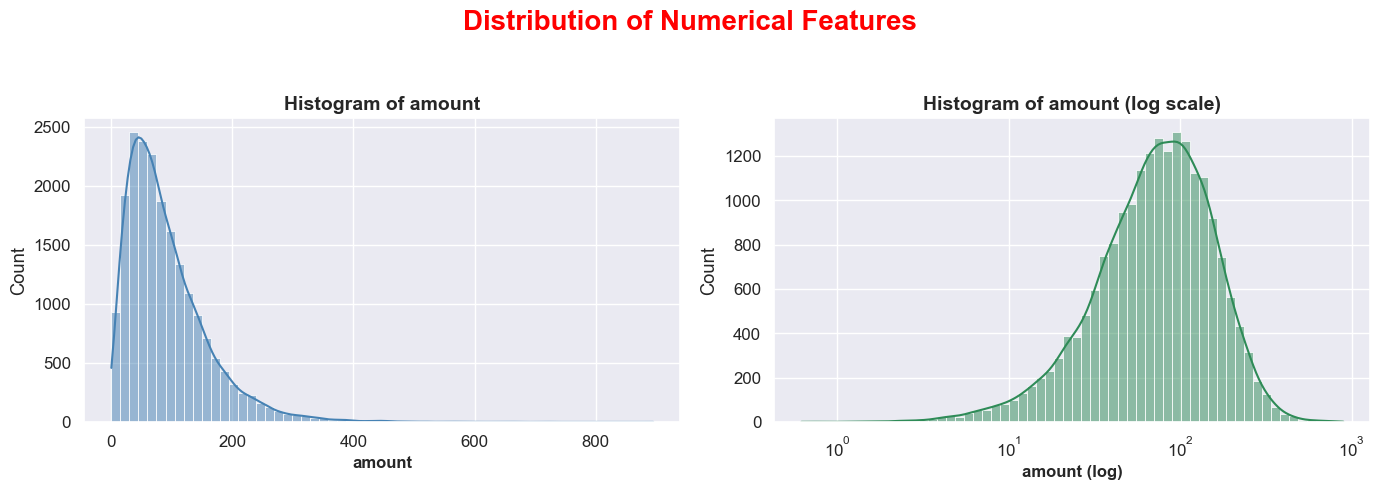

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="amount", ax=axes[0], kde=True, color='steelblue', bins=60)
axes[0].set_title("Histogram of amount", fontweight="bold", fontsize=14)
axes[0].set_xlabel("amount", fontsize=12, fontweight="bold")

sns.histplot(data=df, x="amount", ax=axes[1], kde=True, color='seagreen', bins=60, log_scale=(True, False))
axes[1].set_title("Histogram of amount (log scale)", fontweight="bold", fontsize=14)
axes[1].set_xlabel("amount (log)", fontsize=12, fontweight="bold")

plt.suptitle("Distribution of Numerical Features", fontsize=20, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

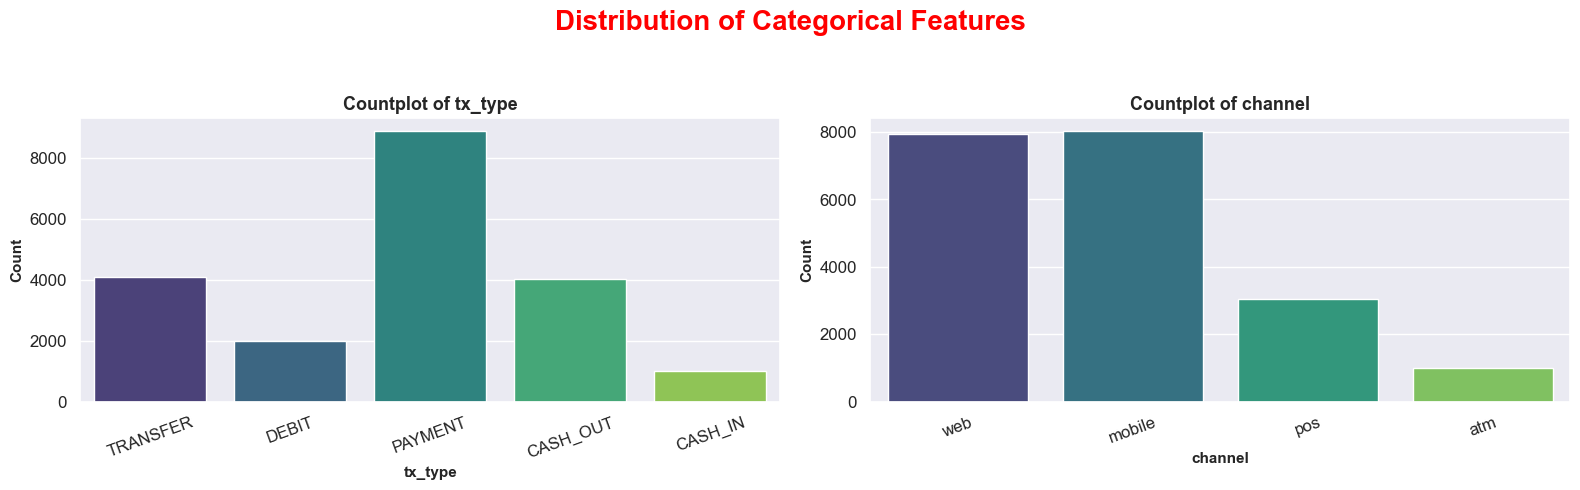

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, feature in enumerate(categorical_features):
    sns.countplot(data=df, x=feature, ax=axes[i], palette='viridis')
    axes[i].set_title(f"Countplot of {feature}", fontweight="bold", fontsize=13)
    axes[i].set_xlabel(feature, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Count", fontsize=11, fontweight="bold")
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle("Distribution of Categorical Features", fontsize=20, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## Target Analysis (Fraud vs Legitimate)

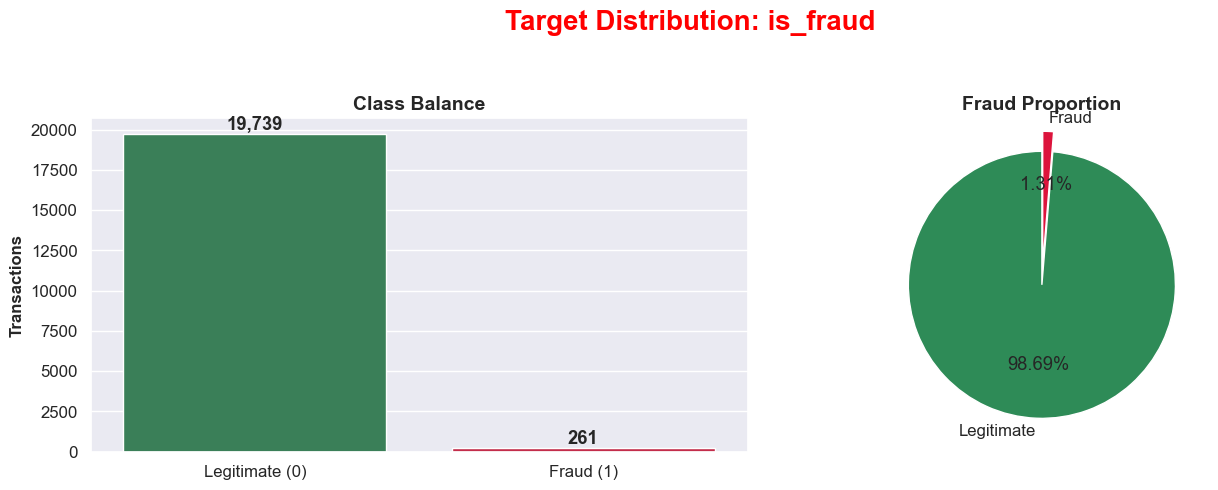

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df[target].value_counts().sort_index()
sns.barplot(x=["Legitimate (0)", "Fraud (1)"], y=counts.values, ax=axes[0], palette=["seagreen", "crimson"])
axes[0].set_title("Class Balance", fontweight="bold", fontsize=14)
axes[0].set_ylabel("Transactions", fontsize=12, fontweight="bold")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")

axes[1].pie(counts.values, labels=["Legitimate", "Fraud"], autopct="%1.2f%%",
            colors=["seagreen", "crimson"], startangle=90, explode=(0, 0.15))
axes[1].set_title("Fraud Proportion", fontweight="bold", fontsize=14)

plt.suptitle("Target Distribution: is_fraud", fontsize=20, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## Bivariate Analysis

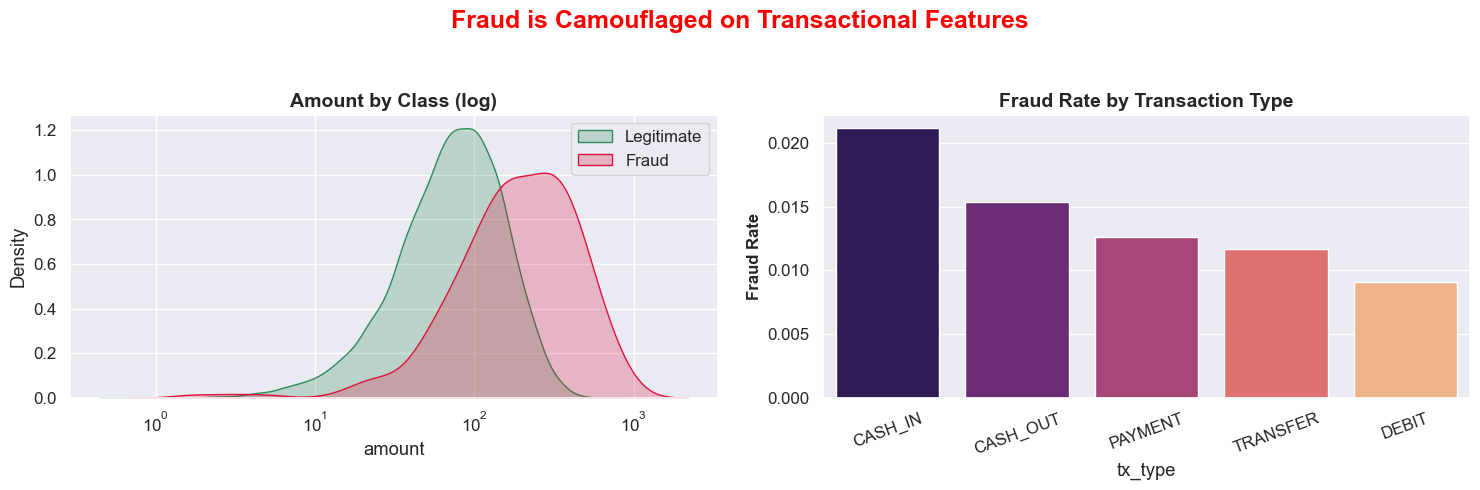

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Amount distribution by class -- note how fraud overlaps legitimate traffic (camouflage).
sns.kdeplot(data=df[df[target] == 0], x="amount", ax=axes[0], fill=True, color="seagreen", label="Legitimate", log_scale=True)
sns.kdeplot(data=df[df[target] == 1], x="amount", ax=axes[0], fill=True, color="crimson", label="Fraud", log_scale=True)
axes[0].set_title("Amount by Class (log)", fontweight="bold", fontsize=14)
axes[0].legend()

# Fraud rate by transaction type.
rate = df.groupby("tx_type")[target].mean().sort_values(ascending=False)
sns.barplot(x=rate.index, y=rate.values, ax=axes[1], palette="magma")
axes[1].set_title("Fraud Rate by Transaction Type", fontweight="bold", fontsize=14)
axes[1].set_ylabel("Fraud Rate", fontsize=12, fontweight="bold")
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle("Fraud is Camouflaged on Transactional Features", fontsize=18, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# 🕸️ Graph Feature Engineering

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    This is the heart of the project. We build a <b>heterogeneous, weighted transaction graph</b> for each sliding one-hour
    window &mdash; nodes are <b>accounts</b>, <b>devices</b>, and <b>merchants</b>; each transaction links an account to the
    device and merchant it used. On this graph we compute the 15 real-time graph features that expose coordinated fraud:
    a small device pool shared by many accounts forms a dense, high-degree subgraph that no tabular feature can reveal.
</div>

## 🧰 The 15 Graph Features

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    For each window graph we compute centrality (PageRank, betweenness), local structure (degree, clustering coefficient,
    connected-component size), and velocity / fan-out signals, then join them back onto every transaction by its account,
    device and merchant nodes. In production this is computed with Spark GraphFrames per micro-batch; here we use NetworkX
    so the notebook runs anywhere.
</div>

In [14]:
def node_key(node_type: str, node_id: str) -> str:
    """Namespaced node identifier, e.g. ``acct:A000123``."""
    return f"{node_type}:{node_id}"


def build_transaction_graph(window_df: pd.DataFrame) -> nx.Graph:
    """Undirected, weighted account-device-merchant graph for one window."""
    graph = nx.Graph()
    for row in window_df.itertuples(index=False):
        acct = node_key("acct", row.account_id)
        dev = node_key("dev", row.device_id)
        mer = node_key("mer", row.merchant_id)
        graph.add_node(acct, ntype="account")
        graph.add_node(dev, ntype="device")
        graph.add_node(mer, ntype="merchant")
        _bump_edge(graph, acct, dev, row.amount)
        _bump_edge(graph, acct, mer, row.amount)
    return graph


def _bump_edge(graph, u, v, amount):
    if graph.has_edge(u, v):
        graph[u][v]["weight"] += 1
        graph[u][v]["amount"] += float(amount)
    else:
        graph.add_edge(u, v, weight=1, amount=float(amount))

In [15]:
GRAPH_FEATURE_NAMES = [
    "account_degree", "account_pagerank", "account_clustering_coef", "account_betweenness",
    "device_degree", "device_betweenness_centrality", "device_pagerank", "device_shared_account_count",
    "merchant_degree", "merchant_cluster_coefficient", "merchant_betweenness",
    "velocity_ring_score", "component_size", "unique_devices_per_account", "unique_merchants_per_account",
]


def _safe_betweenness(graph):
    n = graph.number_of_nodes()
    if n == 0:
        return {}
    k = None if n <= 400 else min(200, n)  # sample pivots on large windows
    try:
        return nx.betweenness_centrality(graph, k=k, weight=None, seed=7)
    except Exception:
        return {node: 0.0 for node in graph.nodes}


def _account_neighbour_count(graph, acct, prefix):
    if acct not in graph:
        return 0
    return sum(1 for nbr in graph.neighbors(acct) if nbr.startswith(f"{prefix}:"))


def compute_graph_features(graph: nx.Graph, window_df: pd.DataFrame) -> pd.DataFrame:
    """Per-transaction DataFrame of the 15 graph features, aligned to window_df."""
    if graph.number_of_nodes() == 0:
        return pd.DataFrame(0.0, index=window_df["tx_id"], columns=GRAPH_FEATURE_NAMES).reset_index()

    pagerank = nx.pagerank(graph, weight="weight", max_iter=100)
    betweenness = _safe_betweenness(graph)
    clustering = nx.clustering(graph)
    degree = dict(graph.degree())

    comp_size = {}
    for comp in nx.connected_components(graph):
        for node in comp:
            comp_size[node] = len(comp)

    velocity = window_df.groupby("account_id").size().to_dict()

    rows = []
    for tx in window_df.itertuples(index=False):
        acct = node_key("acct", tx.account_id)
        dev = node_key("dev", tx.device_id)
        mer = node_key("mer", tx.merchant_id)
        rows.append({
            "tx_id": tx.tx_id,
            "account_degree": degree.get(acct, 0),
            "account_pagerank": pagerank.get(acct, 0.0),
            "account_clustering_coef": clustering.get(acct, 0.0),
            "account_betweenness": betweenness.get(acct, 0.0),
            "device_degree": degree.get(dev, 0),
            "device_betweenness_centrality": betweenness.get(dev, 0.0),
            "device_pagerank": pagerank.get(dev, 0.0),
            "device_shared_account_count": degree.get(dev, 0),
            "merchant_degree": degree.get(mer, 0),
            "merchant_cluster_coefficient": clustering.get(mer, 0.0),
            "merchant_betweenness": betweenness.get(mer, 0.0),
            "velocity_ring_score": velocity.get(tx.account_id, 1),
            "component_size": comp_size.get(acct, 1),
            "unique_devices_per_account": _account_neighbour_count(graph, acct, "dev"),
            "unique_merchants_per_account": _account_neighbour_count(graph, acct, "mer"),
        })
    return pd.DataFrame(rows)

In [16]:
# Slide a one-hour window over the stream, build a graph per window and compute
# the 15 features. Feature vectors are materialised once and reused downstream.
df = df.sort_values("event_time").reset_index(drop=True)
df["window"] = df["event_time"].dt.floor("60min")

feature_frames = []
for win, window_df in df.groupby("window"):
    graph = build_transaction_graph(window_df)
    feature_frames.append(compute_graph_features(graph, window_df))
    print(f"window {win}  |  tx={len(window_df):5d}  nodes={graph.number_of_nodes():5d}  edges={graph.number_of_edges():5d}")

graph_features = pd.concat(feature_frames, ignore_index=True)
df = df.merge(graph_features, on="tx_id", how="left")
print("\nGraph features attached:", graph_features.shape)
graph_features.head()

window 2023-11-14 22:00:00  |  tx= 2592  nodes= 4109  edges= 5176


window 2023-11-14 23:00:00  |  tx= 3334  nodes= 4755  edges= 6651


window 2023-11-15 00:00:00  |  tx= 3333  nodes= 4792  edges= 6648


window 2023-11-15 01:00:00  |  tx= 3333  nodes= 4756  edges= 6645


window 2023-11-15 02:00:00  |  tx= 3334  nodes= 4706  edges= 6656


window 2023-11-15 03:00:00  |  tx= 3333  nodes= 4720  edges= 6649
window 2023-11-15 04:00:00  |  tx=  741  nodes= 1731  edges= 1481

Graph features attached: (20000, 16)


,tx_id,account_degree,account_pagerank,account_clustering_coef,account_betweenness,device_degree,device_betweenness_centrality,device_pagerank,device_shared_account_count,merchant_degree,merchant_cluster_coefficient,merchant_betweenness,velocity_ring_score,component_size,unique_devices_per_account,unique_merchants_per_account
0,T000000000,4,0.000365,0,0.002994,2,0.000095,0.000194,2,5,0,0.003400,2,4034,2,2
1,T000000001,6,0.000453,0,0.018166,14,0.043272,0.001020,14,3,0,0.004137,3,4034,3,3
2,T000000002,4,0.000372,0,0.000673,2,0.000289,0.000187,2,1,0,0.000000,2,4034,2,2
3,T000000003,4,0.000393,0,0.000647,1,0.000000,0.000120,1,2,0,0.000664,2,4034,2,2
4,T000000004,6,0.000518,0,0.001936,1,0.000000,0.000110,1,4,0,0.001804,3,4034,3,3


In [17]:
# How strongly does each graph feature separate fraud from legitimate traffic?
sep = (df.groupby(target)[GRAPH_FEATURE_NAMES].mean().T)
sep.columns = ["Legitimate", "Fraud"]
sep["ratio (fraud / legit)"] = (sep["Fraud"] / sep["Legitimate"].replace(0, np.nan)).round(2)
sep.round(4).sort_values("ratio (fraud / legit)", ascending=False)

,Legitimate,Fraud,ratio (fraud / legit)
account_betweenness,0.0024,0.0034,1.38
velocity_ring_score,1.7876,2.4559,1.37
merchant_betweenness,0.0036,0.0047,1.31
merchant_degree,4.9312,6.1188,1.24
unique_merchants_per_account,1.7851,2.2031,1.23
device_pagerank,0.0003,0.0004,1.18
account_degree,3.5694,4.1111,1.15
account_pagerank,0.0003,0.0003,1.15
device_degree,4.3394,4.8238,1.11
device_shared_account_count,4.3394,4.8238,1.11


## 🚨 Fraud Ring Detection

In [18]:
@dataclass
class FraudRing:
    ring_id: int
    accounts: list = field(default_factory=list)
    devices: list = field(default_factory=list)
    merchants: list = field(default_factory=list)
    shared_device_ratio: float = 0.0
    density: float = 0.0
    size: int = 0

    @property
    def risk_score(self) -> float:
        return round(min(1.0, 0.5 * self.density + 0.5 * self.shared_device_ratio), 4)


def detect_fraud_rings(graph: nx.Graph, min_accounts: int = 3):
    """Label-Propagation communities of 3+ accounts sharing devices/merchants."""
    if graph.number_of_nodes() == 0:
        return []
    communities = nx.community.label_propagation_communities(graph)
    rings, ring_id = [], 0
    for community in communities:
        accounts = [n for n in community if n.startswith("acct:")]
        if len(accounts) < min_accounts:
            continue
        devices = [n for n in community if n.startswith("dev:")]
        merchants = [n for n in community if n.startswith("mer:")]
        sub = graph.subgraph(community)
        shared = 1.0 - min(1.0, len(devices) / len(accounts)) if accounts else 0.0
        rings.append(FraudRing(ring_id, accounts, devices, merchants,
                               round(shared, 4), round(nx.density(sub), 4), len(accounts)))
        ring_id += 1
    rings.sort(key=lambda r: r.risk_score, reverse=True)
    return rings


# Run ring detection on the busiest window.
busiest = df["window"].value_counts().idxmax()
busiest_graph = build_transaction_graph(df[df["window"] == busiest])
rings = detect_fraud_rings(busiest_graph)

print(f"Detected {len(rings)} candidate fraud rings in window {busiest}\n")
pd.DataFrame([{
    "ring_id": r.ring_id, "size": r.size, "devices": len(r.devices),
    "merchants": len(r.merchants), "shared_device_ratio": r.shared_device_ratio,
    "density": r.density, "risk_score": r.risk_score,
} for r in rings[:10]])

Detected 149 candidate fraud rings in window 2023-11-14 23:00:00



,ring_id,size,devices,merchants,shared_device_ratio,density,risk_score
0,43,3,0,1,1.0000,0.5000,0.7500
1,52,3,0,1,1.0000,0.5000,0.7500
2,71,3,0,1,1.0000,0.5000,0.7500
3,82,3,0,1,1.0000,0.5000,0.7500
4,114,3,0,1,1.0000,0.5000,0.7500
5,117,3,0,1,1.0000,0.5000,0.7500
6,132,3,0,1,1.0000,0.5000,0.7500
7,146,3,0,1,1.0000,0.5000,0.7500
8,1,5,1,2,0.8000,0.3929,0.5965
9,45,3,1,0,0.6667,0.5000,0.5834


# 🛠️ Feature Engineering & Preprocessing

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Before training we assemble two feature sets so we can isolate the contribution of the graph:
    a <b>tabular-only</b> set (amount + encoded transaction type and channel) and a <b>graph-enhanced</b>
    set (tabular + the 15 graph features). Both share the same train/test split so the comparison is fair.
</div>

## 🔧 Key Preprocessing Steps

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li><strong>Encoding categorical variables:</strong> one-hot encode <code>tx_type</code> and <code>channel</code>.</li>
        <li><strong>Amount transformation:</strong> log1p the heavily skewed <code>amount</code> column.</li>
        <li><strong>Feature sets:</strong> define the tabular baseline columns and the graph-enhanced columns.</li>
        <li><strong>Stratified split:</strong> preserve the fraud ratio across train and test.</li>
    </ul>
</div>

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

model_df = df.copy()
model_df["log_amount"] = np.log1p(model_df["amount"])

# One-hot encode the low-cardinality categoricals.
model_df = pd.get_dummies(model_df, columns=["tx_type", "channel"], prefix=["type", "chan"])
ohe_cols = [c for c in model_df.columns if c.startswith(("type_", "chan_"))]

tabular_features = ["log_amount"] + ohe_cols
graph_enhanced_features = tabular_features + GRAPH_FEATURE_NAMES

print(f"Tabular features      : {len(tabular_features)}")
print(f"Graph-enhanced features: {len(graph_enhanced_features)}")

Tabular features      : 10
Graph-enhanced features: 25


In [20]:
X = model_df[graph_enhanced_features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train fraud rate:", round(y_train.mean(), 4), "| Test fraud rate:", round(y_test.mean(), 4))

Train: (15000, 25) | Test: (5000, 25)
Train fraud rate: 0.0131 | Test fraud rate: 0.013


# 🏗️ Model Building

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    We train the <b>same XGBoost model twice</b> &mdash; once on tabular features only, once on tabular + graph features &mdash;
    and report the AUC uplift. This quantifies the project's core claim: the fraud is deliberately camouflaged on
    transactional features, so the graph signal is what makes it detectable.
</div>

## 🔭 Choice of Models

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li><strong>XGBoost:</strong> gradient-boosted trees with class-imbalance weighting &mdash; the production champion.</li>
        <li><strong>CatBoost:</strong> a strong challenger averaged into the ensemble.</li>
        <li><strong>Ensemble (meta learner):</strong> average the two probabilities for the final fraud score.</li>
    </ul>
</div>

In [21]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / max(1, (y_train == 1).sum())

def fit_xgb(feature_cols):
    clf = XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.9, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="auc", random_state=42, n_jobs=-1,
    )
    clf.fit(X_train[feature_cols], y_train)
    proba = clf.predict_proba(X_test[feature_cols])[:, 1]
    return clf, proba

In [22]:
# 1) Tabular-only baseline
xgb_tab, proba_tab = fit_xgb(tabular_features)
auc_tab = roc_auc_score(y_test, proba_tab)
ap_tab = average_precision_score(y_test, proba_tab)
print(f"Tabular-only  ->  AUC: {auc_tab:.4f}  |  PR-AUC: {ap_tab:.4f}")

Tabular-only  ->  AUC: 0.7547  |  PR-AUC: 0.2413


In [23]:
# 2) Graph-enhanced model
xgb_graph, proba_graph = fit_xgb(graph_enhanced_features)
auc_graph = roc_auc_score(y_test, proba_graph)
ap_graph = average_precision_score(y_test, proba_graph)
print(f"Graph-enhanced ->  AUC: {auc_graph:.4f}  |  PR-AUC: {ap_graph:.4f}")
print(f"\nAUC uplift from graph features: +{auc_graph - auc_tab:.4f}")

Graph-enhanced ->  AUC: 0.9217  |  PR-AUC: 0.6972

AUC uplift from graph features: +0.1670


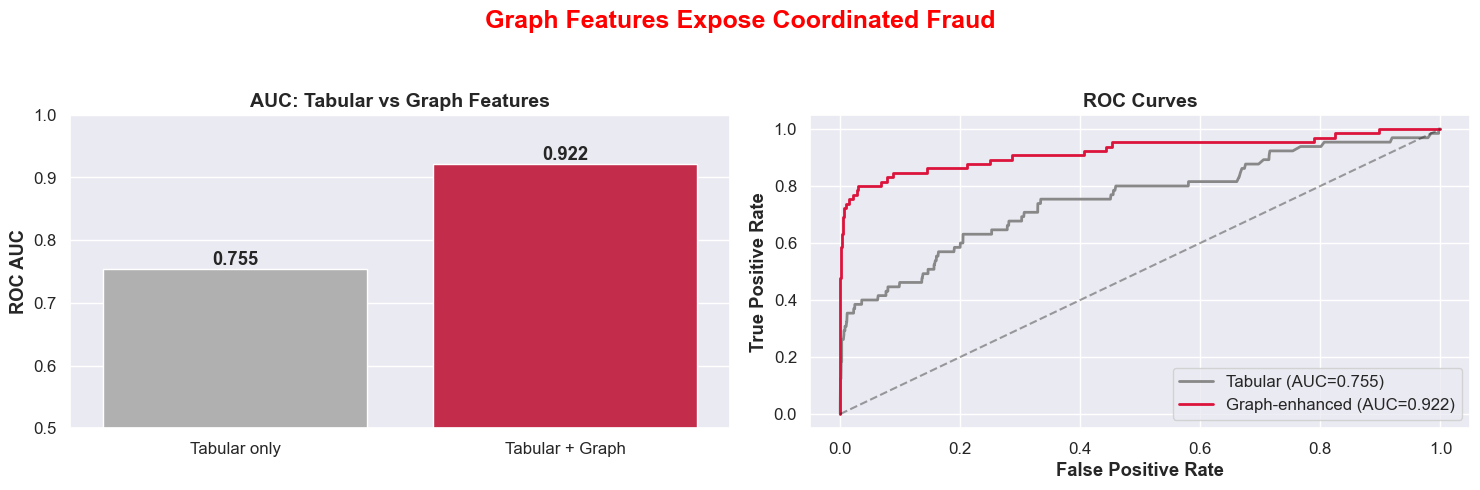

In [24]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# AUC comparison bar chart
sns.barplot(x=["Tabular only", "Tabular + Graph"], y=[auc_tab, auc_graph],
            ax=axes[0], palette=["#b0b0b0", "crimson"])
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title("AUC: Tabular vs Graph Features", fontweight="bold", fontsize=14)
axes[0].set_ylabel("ROC AUC", fontweight="bold")
for i, v in enumerate([auc_tab, auc_graph]):
    axes[0].text(i, v, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")

# ROC curves
for proba, lbl, col in [(proba_tab, "Tabular", "#888888"), (proba_graph, "Graph-enhanced", "crimson")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, label=f"{lbl} (AUC={roc_auc_score(y_test, proba):.3f})", color=col, lw=2)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_xlabel("False Positive Rate", fontweight="bold")
axes[1].set_ylabel("True Positive Rate", fontweight="bold")
axes[1].set_title("ROC Curves", fontweight="bold", fontsize=14)
axes[1].legend()

plt.suptitle("Graph Features Expose Coordinated Fraud", fontsize=18, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## Meta Learner (XGBoost + CatBoost Ensemble)

In [25]:
try:
    from catboost import CatBoostClassifier
    cat = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        loss_function="Logloss", eval_metric="AUC",
        scale_pos_weight=scale_pos_weight, random_seed=42, verbose=0,
    )
    cat.fit(X_train[graph_enhanced_features], y_train)
    proba_cat = cat.predict_proba(X_test[graph_enhanced_features])[:, 1]
    auc_cat = roc_auc_score(y_test, proba_cat)
    print(f"CatBoost (graph) -> AUC: {auc_cat:.4f}")
except Exception as e:
    print("CatBoost unavailable, falling back to XGBoost only:", e)
    proba_cat = proba_graph

# Ensemble: average the two probabilities (the production champion/challenger blend).
proba_ensemble = (proba_graph + proba_cat) / 2.0
auc_ensemble = roc_auc_score(y_test, proba_ensemble)
print(f"Ensemble (XGB + CatBoost) -> AUC: {auc_ensemble:.4f}  |  PR-AUC: {average_precision_score(y_test, proba_ensemble):.4f}")

CatBoost (graph) -> AUC: 0.9092
Ensemble (XGB + CatBoost) -> AUC: 0.9137  |  PR-AUC: 0.6937


## Feature Importance

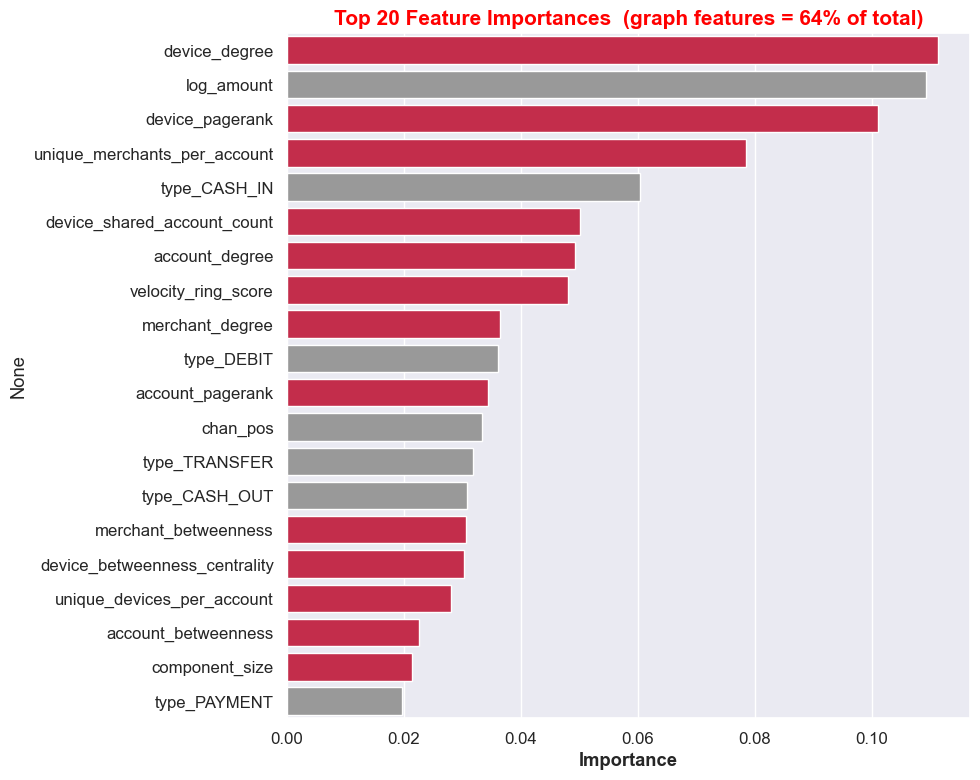

Graph features account for 64.2% of the model's total importance.


In [26]:
importances = pd.Series(xgb_graph.feature_importances_, index=graph_enhanced_features).sort_values(ascending=False)
graph_share = importances[GRAPH_FEATURE_NAMES].sum() / importances.sum()

plt.figure(figsize=(10, 8))
top = importances.head(20)
colors = ["crimson" if f in GRAPH_FEATURE_NAMES else "#999999" for f in top.index]
sns.barplot(x=top.values, y=top.index, palette=colors)
plt.title(f"Top 20 Feature Importances  (graph features = {graph_share:.0%} of total)",
          fontsize=15, fontweight="bold", color="red")
plt.xlabel("Importance", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Graph features account for {graph_share:.1%} of the model's total importance.")

# 🚓 Inline Scoring & Decisions

<div class="alert alert-block alert-warning" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Finally, each fraud probability is turned into a routing decision using configurable thresholds, exactly as the
    production scorer does:
    <ul>
        <li><b>decline</b> &mdash; score &ge; 0.85</li>
        <li><b>challenge</b> &mdash; score &ge; 0.45</li>
        <li><b>approve</b> &mdash; below 0.45</li>
    </ul>
    Transactions above the high-risk threshold are flagged for the LangChain Fraud Investigation Agent.
</div>

In [27]:
DECLINE_THRESHOLD = 0.85
CHALLENGE_THRESHOLD = 0.45

def decide(score):
    if score >= DECLINE_THRESHOLD:
        return "decline"
    if score >= CHALLENGE_THRESHOLD:
        return "challenge"
    return "approve"

scored = X_test.copy()
scored["fraud_score"] = proba_ensemble
scored["is_fraud"] = y_test.values
scored["decision"] = scored["fraud_score"].apply(decide)

print("Decision distribution:")
print(scored["decision"].value_counts(), "\n")

# Sample of the highest-risk transactions.
scored.sort_values("fraud_score", ascending=False)[["fraud_score", "decision", "is_fraud"]].head(10)

Decision distribution:
decision
approve      4932
decline        38
challenge      30
Name: count, dtype: int64 



,fraud_score,decision,is_fraud
18227,0.999985,decline,1
16502,0.999984,decline,1
17174,0.999944,decline,1
4302,0.999748,decline,1
5644,0.999742,decline,1
5166,0.999739,decline,1
17665,0.999659,decline,1
10386,0.999646,decline,1
10277,0.999573,decline,1
9536,0.999528,decline,1


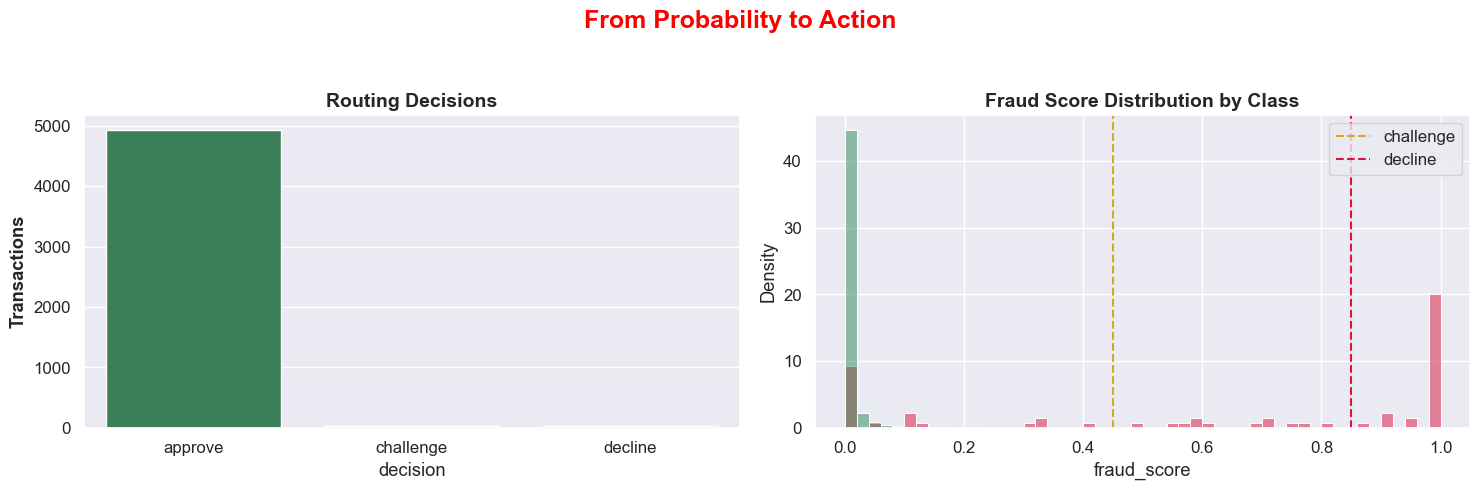

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order = ["approve", "challenge", "decline"]
sns.countplot(data=scored, x="decision", order=order, palette=["seagreen", "goldenrod", "crimson"], ax=axes[0])
axes[0].set_title("Routing Decisions", fontweight="bold", fontsize=14)
axes[0].set_ylabel("Transactions", fontweight="bold")

sns.histplot(data=scored, x="fraud_score", hue="is_fraud", bins=50, ax=axes[1],
             palette={0: "seagreen", 1: "crimson"}, stat="density", common_norm=False)
axes[1].axvline(CHALLENGE_THRESHOLD, color="goldenrod", ls="--", label="challenge")
axes[1].axvline(DECLINE_THRESHOLD, color="crimson", ls="--", label="decline")
axes[1].set_title("Fraud Score Distribution by Class", fontweight="bold", fontsize=14)
axes[1].legend()

plt.suptitle("From Probability to Action", fontsize=18, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# ✅ Conclusion

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    In this notebook we built an end-to-end, graph-enhanced fraud-detection pipeline:
    <ul>
        <li>Generated a realistic streaming transaction graph with planted, camouflaged fraud rings.</li>
        <li>Confirmed through EDA that fraud is <b>invisible</b> on transactional features alone.</li>
        <li>Built a sliding one-hour transaction graph and engineered the <b>15 real-time graph features</b>.</li>
        <li>Detected coordinated fraud rings with the <b>Label Propagation Algorithm</b>.</li>
        <li>Showed a clear <b>AUC uplift</b> from graph features, with an XGBoost + CatBoost ensemble.</li>
        <li>Confirmed graph features dominate model importance, and turned scores into <code>approve</code> / <code>challenge</code> / <code>decline</code> decisions.</li>
    </ul>
    <b>The structure that links accounts, devices, and merchants is what exposes fraud rings invisible to any single transaction.</b>
</div>

***Thank you for reading, happy building.***

<center>
    <img src="https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExMXo3ZjUzbG1taXE1eGdkcWNubHkxdTlsNjEzZ2JwY2p2b2hqbTV5aSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9cw/Gz6nYcm8oXE4dFTC8j/giphy.gif" height="120" width="240">
</center>
